<a href="https://colab.research.google.com/github/MakwBansari/EduNetGTU/blob/main/part2_day6_11_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Logistic Regression**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [4]:
from google.colab import files

uploaded = files.upload()

Saving climate_change_indicators.csv to climate_change_indicators (1).csv


In [5]:
climate_df = pd.read_csv("climate_change_indicators.csv")

climate_df.head()

print("Shape")
print(climate_df.shape)

print("\nColumns")
print(climate_df.columns)

print("\nInfo")
print(climate_df.info())

print("\nDescribe")
print(climate_df.describe())

print("\nMissing Values")
print(climate_df.isnull().sum())

Shape
(225, 72)

Columns
Index(['ObjectId', 'Country', 'ISO2', 'ISO3', 'Indicator', 'Unit', 'Source',
       'CTS_Code', 'CTS_Name', 'CTS_Full_Descriptor', 'F1961', 'F1962',
       'F1963', 'F1964', 'F1965', 'F1966', 'F1967', 'F1968', 'F1969', 'F1970',
       'F1971', 'F1972', 'F1973', 'F1974', 'F1975', 'F1976', 'F1977', 'F1978',
       'F1979', 'F1980', 'F1981', 'F1982', 'F1983', 'F1984', 'F1985', 'F1986',
       'F1987', 'F1988', 'F1989', 'F1990', 'F1991', 'F1992', 'F1993', 'F1994',
       'F1995', 'F1996', 'F1997', 'F1998', 'F1999', 'F2000', 'F2001', 'F2002',
       'F2003', 'F2004', 'F2005', 'F2006', 'F2007', 'F2008', 'F2009', 'F2010',
       'F2011', 'F2012', 'F2013', 'F2014', 'F2015', 'F2016', 'F2017', 'F2018',
       'F2019', 'F2020', 'F2021', 'F2022'],
      dtype='object')

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  ----

# **Handle Missing Values**

In [6]:

numeric_cols = climate_df.select_dtypes(include=np.number).columns

climate_df[numeric_cols] = climate_df[numeric_cols].fillna(
    climate_df[numeric_cols].mean()
)

# Categorical Columns

categorical_cols = climate_df.select_dtypes(include="object").columns

for col in categorical_cols:
    climate_df[col] = climate_df[col].fillna(
        climate_df[col].mode()[0]
    )

print(climate_df.isnull().sum())

ObjectId     0
Country      0
ISO2         0
ISO3         0
Indicator    0
            ..
F2018        0
F2019        0
F2020        0
F2021        0
F2022        0
Length: 72, dtype: int64


# **Feature Engineering**

In [7]:
year_columns = [col for col in climate_df.columns if col.startswith("F")]

climate_df["Average_Temperature"] = climate_df[year_columns].mean(axis=1)

climate_df.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor,...,F2014,F2015,F2016,F2017,F2018,F2019,F2020,F2021,F2022,Average_Temperature
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,0.456,1.093,1.555,1.540,1.544,0.910,0.498,1.327,2.012,0.484661
1,2,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.198,1.569,1.464,1.121,2.028,1.675,1.498,1.536,1.518,0.471387
2,3,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.690,1.121,1.757,1.512,1.210,1.115,1.926,2.330,1.688,0.724871
3,4,American Samoa,AS,ASM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.170,1.009,1.539,1.435,1.189,1.539,1.430,1.268,1.256,0.492368
4,5,"Andorra, Principality of",AD,AND,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.946,1.690,1.990,1.925,1.919,1.964,2.562,1.533,3.243,0.792806


# **Create Target Variable**

In [8]:
climate_df["Temperature_Category"] = pd.cut(
    climate_df["Average_Temperature"],
    bins=3,
    labels=["Low","Medium","High"]
)

climate_df.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor,...,F2015,F2016,F2017,F2018,F2019,F2020,F2021,F2022,Average_Temperature,Temperature_Category
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.093,1.555,1.540,1.544,0.910,0.498,1.327,2.012,0.484661,Medium
1,2,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.569,1.464,1.121,2.028,1.675,1.498,1.536,1.518,0.471387,Medium
2,3,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.121,1.757,1.512,1.210,1.115,1.926,2.330,1.688,0.724871,High
3,4,American Samoa,AS,ASM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.009,1.539,1.435,1.189,1.539,1.430,1.268,1.256,0.492368,Medium
4,5,"Andorra, Principality of",AD,AND,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.690,1.990,1.925,1.919,1.964,2.562,1.533,3.243,0.792806,High


# **Seaborn Histogram**

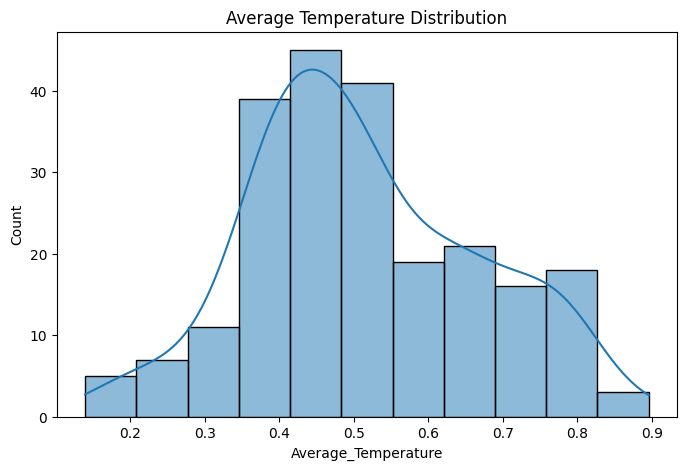

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    climate_df["Average_Temperature"],
    kde=True
)

plt.title("Average Temperature Distribution")

plt.show()

# **Boxplot**

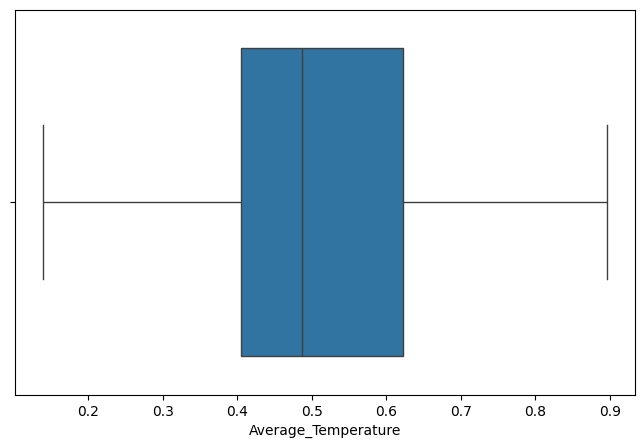

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=climate_df["Average_Temperature"]
)

plt.show()

# **Count Plot**

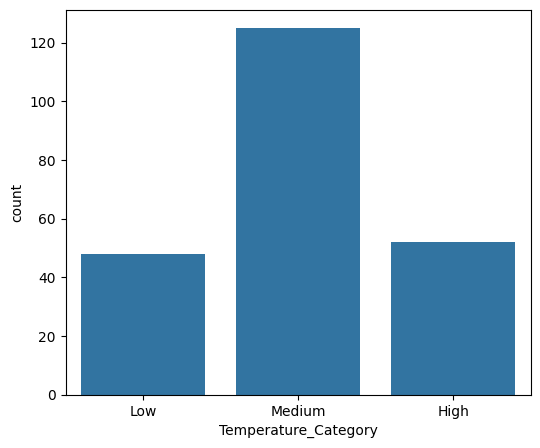

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Temperature_Category",
    data=climate_df
)

plt.show()

# **Heatmap**

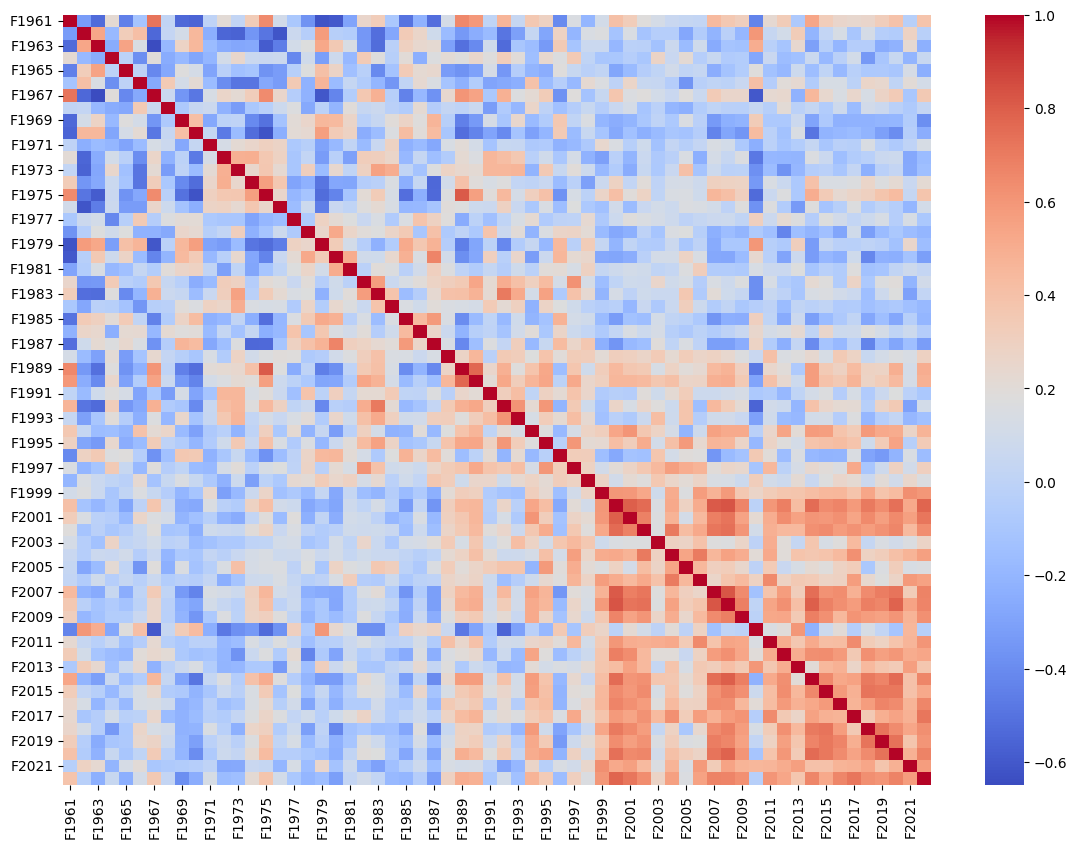

In [12]:
plt.figure(figsize=(14,10))

sns.heatmap(
    climate_df[year_columns].corr(),
    cmap="coolwarm"
)

plt.show()

# **Scaling**

In [13]:
scaler = StandardScaler()

climate_df[year_columns] = scaler.fit_transform(
    climate_df[year_columns]
)

# **Encoding**

In [14]:
encoder = LabelEncoder()

object_cols = climate_df.select_dtypes(include="object").columns

for col in object_cols:
    climate_df[col] = encoder.fit_transform(climate_df[col])

climate_df["Temperature_Category"] = encoder.fit_transform(
    climate_df["Temperature_Category"]
)

# **Select Features**

In [15]:
feature_columns = year_columns + [
    "Country",
    "Indicator",
    "Unit"
]

X = climate_df[feature_columns]

y = climate_df["Temperature_Category"]

# **Train Test Split**

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(180, 65)
(45, 65)


# **Logistic Regression**

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# **Prediction**

In [18]:
y_pred = model.predict(X_test)

# **Evaluation**

In [19]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Accuracy :", accuracy_score(y_test,y_pred))

print("Precision :", precision_score(y_test,y_pred,average="weighted"))

print("Recall :", recall_score(y_test,y_pred,average="weighted"))

print("F1 Score :", f1_score(y_test,y_pred,average="weighted"))

print("\nConfusion Matrix")

print(confusion_matrix(y_test,y_pred))

print("\nClassification Report")

print(classification_report(y_test,y_pred))

Accuracy : 0.9555555555555556
Precision : 0.962962962962963
Recall : 0.9555555555555556
F1 Score : 0.9565175565175565

Confusion Matrix
[[13  0  0]
 [ 0 10  0]
 [ 0  2 20]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.83      1.00      0.91        10
           2       1.00      0.91      0.95        22

    accuracy                           0.96        45
   macro avg       0.94      0.97      0.95        45
weighted avg       0.96      0.96      0.96        45



#  **Insights**

- The dataset contains historical climate change indicators from 1961 to 2022 for different countries.
- Missing values in yearly temperature columns were replaced with the mean because these columns contain continuous numerical data and mean imputation helps preserve the overall trend.
- Missing categorical values were replaced using the mode to retain the most common category.
- A new feature called **Average Temperature** was created to summarize the temperature trend of each country across all available years.
- The target variable **Temperature Category** (Low, Medium, High) was created from the average temperature, making the dataset suitable for a classification problem.
- StandardScaler was applied to the yearly temperature columns so that all numerical features are on a similar scale, which improves the performance of Logistic Regression.
- Label Encoding converted categorical variables such as Country, Indicator, and Unit into numerical values because machine learning algorithms cannot process text directly.
- Seaborn visualizations helped understand the distribution of temperatures, detect outliers, and observe relationships among yearly climate values.
- Logistic Regression successfully classified countries into temperature categories based on historical climate data.